# DDS

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 讓圖表直接顯示在 notebook
%matplotlib inline

# 設定圖表風格（可選，美觀用）
sns.set(style="whitegrid")
print("所有套件匯入完成！")

所有套件匯入完成！


In [8]:
# 請修改成你的實際路徑！
data_path = "D:\phishing_email\data\combined_phishing_dataset_clean.csv"

df = pd.read_csv(data_path)

print(f"資料載入完成！總共 {len(df)} 筆")
print(f"釣魚郵件：{(df['label']==1).sum()} 筆")
print(f"正常郵件：{(df['label']==0).sum()} 筆")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\userback\AppData\Local\Temp\ipykernel_26240\3396503607.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "D:\phishing_email\data\combined_phishing_dataset_clean.csv"


資料載入完成！總共 58385 筆
釣魚郵件：28385 筆
正常郵件：30000 筆


,text,label
0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1
1,"\nÂ \nFree Personal and Business Grants\nÂ "" Q...",1
2,"Greg, as per your request - *2001 bonus number...",0
3,plz call jeff d when you can at 415.505.6633. ...,0
4,your ebay auction payment,1


In [9]:
import nltk
nltk.download('stopwords')  # 第一次跑需要下載

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def get_important_words(text_series, top_n=20):
    all_text = ' '.join(text_series).lower()
    # 移除標點
    all_text = all_text.translate(str.maketrans('', '', string.punctuation))
    words = all_text.split()
    # 移除停用詞與短詞
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(top_n)

print("釣魚郵件重要詞 Top 20：")
print(get_important_words(df[df['label']==1]['text']))

print("\n正常郵件重要詞 Top 20：")
print(get_important_words(df[df['label']==0]['text']))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\userback\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


釣魚郵件重要詞 Top 20：
[('top', 15649), ('news', 13843), ('email', 12784), ('cnncom', 11603), ('2008', 10337), ('time', 9219), ('one', 9064), ('network', 9014), ('cable', 8862), ('cnn', 8801), ('settings', 8694), ('company', 8355), ('please', 7237), ('name', 6674), ('click', 6639), ('going', 6526), ('receive', 6523), ('get', 6446), ('new', 6231), ('daily', 6103)]

正常郵件重要詞 Top 20：
[('subject', 26541), ('enron', 24803), ('please', 21796), ('email', 19845), ('message', 19487), ('would', 19262), ('2001', 18868), ('sent', 16544), ('new', 16428), ('energy', 14808), ('may', 14545), ('original', 14299), ('power', 14260), ('said', 12659), ('know', 12035), ('time', 11948), ('thanks', 11787), ('one', 11491), ('get', 11451), ('gas', 11142)]


C:\Users\userback\AppData\Local\Temp\ipykernel_26240\4171486745.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='url_count', palette=['blue', 'orange'])  # 方法1：用 list 最穩


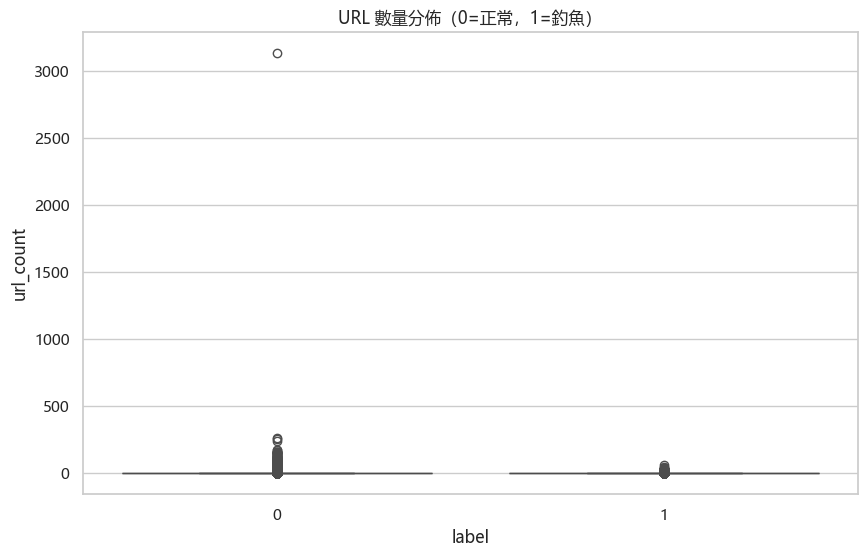

C:\Users\userback\AppData\Local\Temp\ipykernel_26240\4171486745.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='exclamation_count', palette=['blue', 'orange'])


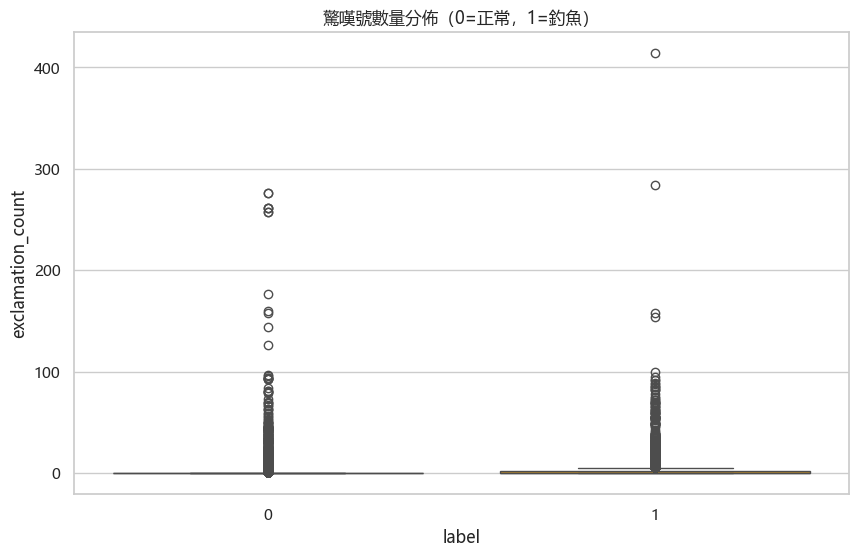

C:\Users\userback\AppData\Local\Temp\ipykernel_26240\4171486745.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='punctuation_ratio', palette=['blue', 'orange'])


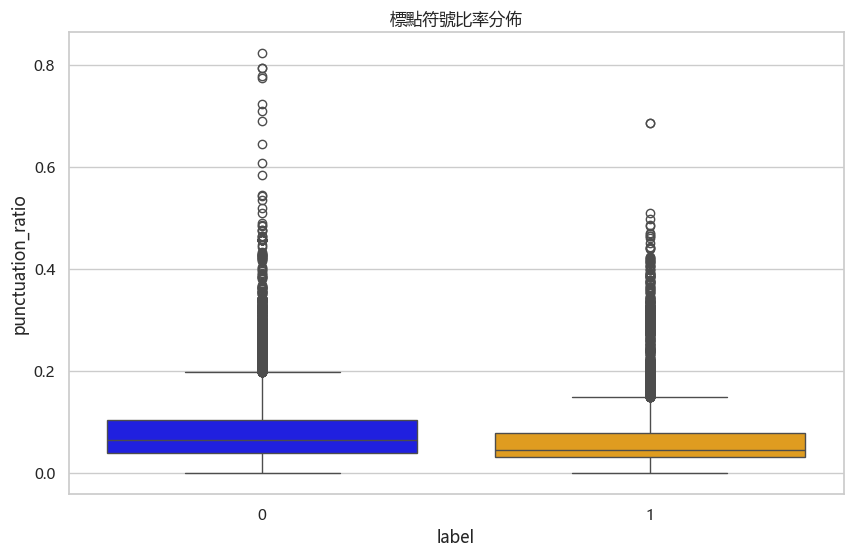

C:\Users\userback\AppData\Local\Temp\ipykernel_26240\4171486745.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='uppercase_ratio', palette=['blue', 'orange'])


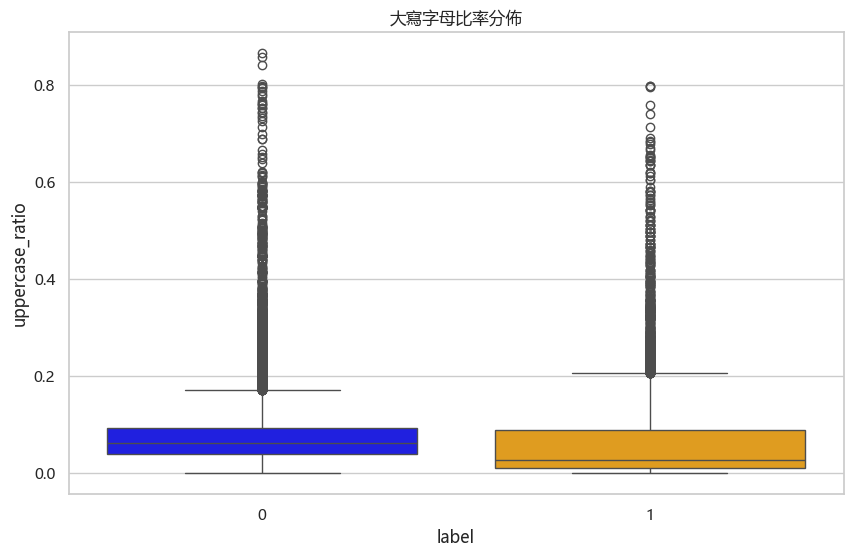

In [12]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# URL 數量
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http[s]?://', str(x))))

# 驚嘆號數量
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))

# 大寫比率
df['uppercase_ratio'] = df['text'].apply(lambda x: sum(c.isupper() for c in str(x)) / len(str(x)) if len(str(x))>0 else 0)

# 標點符號比率
df['punctuation_ratio'] = df['text'].apply(lambda x: sum(c in string.punctuation for c in str(x)) / len(str(x)) if len(str(x))>0 else 0)

# 修正 palette：用字串 key 或直接用 list
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='url_count', palette=['blue', 'orange'])  # 方法1：用 list 最穩
# sns.boxplot(data=df, x='label', y='url_count', palette={'0':'blue', '1':'orange'})  # 方法2：用字串 key
plt.title('URL 數量分佈（0=正常，1=釣魚）')
plt.show()

# 驚嘆號分佈（同樣修正 palette）
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='exclamation_count', palette=['blue', 'orange'])
plt.title('驚嘆號數量分佈（0=正常，1=釣魚）')
plt.show()

# 額外加兩個圖看看其他手工特徵（可選）
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='punctuation_ratio', palette=['blue', 'orange'])
plt.title('標點符號比率分佈')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='uppercase_ratio', palette=['blue', 'orange'])
plt.title('大寫字母比率分佈')
plt.show()

In [14]:
X = df['text']
y = df['label']

# TF-IDF 向量器
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,2)  # 包含 bigram 如 "please click"
)

X_vec = vectorizer.fit_transform(X)

# 分訓練/測試集
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)

print(f"訓練集：{X_train.shape[0]} 筆")
print(f"測試集：{X_test.shape[0]} 筆")

訓練集：46708 筆
測試集：11677 筆


=== 分類報告 ===
              precision    recall  f1-score   support

        正常郵件       0.98      0.98      0.98      6000
        釣魚郵件       0.98      0.98      0.98      5677

    accuracy                           0.98     11677
   macro avg       0.98      0.98      0.98     11677
weighted avg       0.98      0.98      0.98     11677



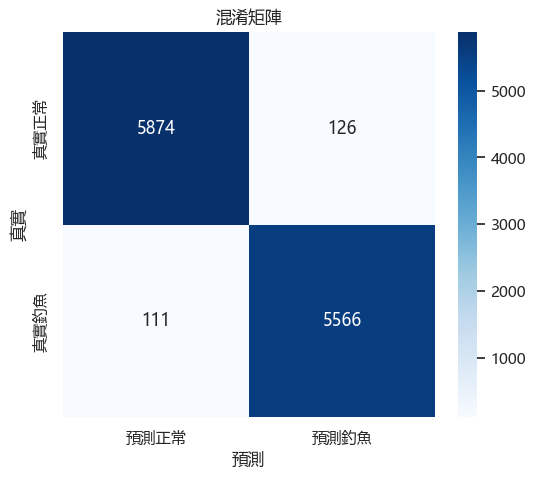

In [16]:
# 訓練 Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 預測
pred = model.predict(X_test)

# 分類報告
print("=== 分類報告 ===")
print(classification_report(y_test, pred, target_names=['正常郵件', '釣魚郵件']))

# 混淆矩陣熱圖
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['預測正常', '預測釣魚'], 
            yticklabels=['真實正常', '真實釣魚'])
plt.xlabel('預測')
plt.ylabel('真實')
plt.title('混淆矩陣')
plt.show()

=== 加入手工特徵後的分類報告 ===
              precision    recall  f1-score   support

        正常郵件       0.98      0.98      0.98      6000
        釣魚郵件       0.98      0.98      0.98      5677

    accuracy                           0.98     11677
   macro avg       0.98      0.98      0.98     11677
weighted avg       0.98      0.98      0.98     11677



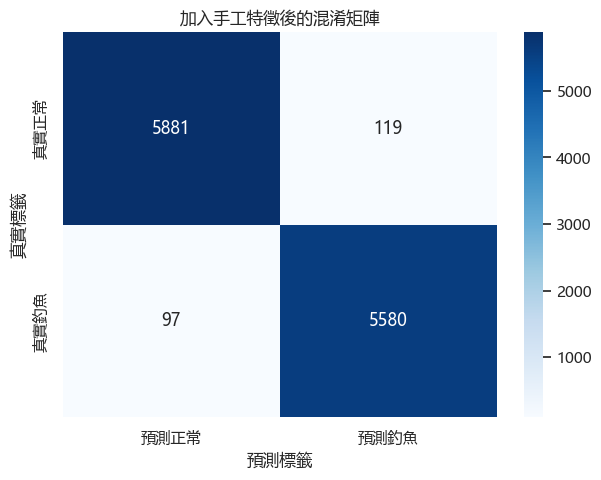

In [17]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

# 取出手工特徵（只選幾個強的）
handcrafted_features = df[['url_count', 'exclamation_count', 'punctuation_ratio', 'uppercase_ratio']]

# 標準化（讓數值尺度一致）
scaler = StandardScaler()
handcrafted_scaled = scaler.fit_transform(handcrafted_features)

# 合併 TF-IDF + 手工特徵
X_combined = hstack([X_vec, handcrafted_scaled])

# 重新分訓練/測試
X_train_comb, X_test_comb, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# 重新訓練
model_comb = LogisticRegression(max_iter=1000)
model_comb.fit(X_train_comb, y_train)

# 評估
pred_comb = model_comb.predict(X_test_comb)
print("=== 加入手工特徵後的分類報告 ===")
print(classification_report(y_test, pred_comb, target_names=['正常郵件', '釣魚郵件']))

# 混淆矩陣（應該會更好！）
cm_comb = confusion_matrix(y_test, pred_comb)
plt.figure(figsize=(7,5))
sns.heatmap(cm_comb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['預測正常', '預測釣魚'],
            yticklabels=['真實正常', '真實釣魚'])
plt.xlabel('預測標籤')
plt.ylabel('真實標籤')
plt.title('加入手工特徵後的混淆矩陣')
plt.show()

In [18]:
import joblib

# 儲存 TF-IDF向量器、手工特徵 scaler、模型
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(scaler, 'handcrafted_scaler.pkl')
joblib.dump(model_comb, 'phishing_detector_model.pkl')

print("模型已儲存！可以拿去部署了")

模型已儲存！可以拿去部署了


In [19]:
import joblib
import pandas as pd
import numpy as np
from scipy.sparse import hstack
import re
import string

# 載入你剛存的模型
vectorizer = joblib.load('tfidf_vectorizer.pkl')
scaler = joblib.load('handcrafted_scaler.pkl')
model = joblib.load('phishing_detector_model.pkl')

def predict_phishing(email_text):
    # 1. TF-IDF 轉換
    text_vec = vectorizer.transform([email_text])
    
    # 2. 提取手工特徵
    url_count = len(re.findall(r'http[s]?://', email_text))
    exclamation_count = email_text.count('!')
    uppercase_ratio = sum(c.isupper() for c in email_text) / len(email_text) if len(email_text)>0 else 0
    punctuation_ratio = sum(c in string.punctuation for c in email_text) / len(email_text) if len(email_text)>0 else 0
    
    handcrafted = np.array([[url_count, exclamation_count, punctuation_ratio, uppercase_ratio]])
    handcrafted_scaled = scaler.transform(handcrafted)
    
    # 3. 合併特徵
    features = hstack([text_vec, handcrafted_scaled])
    
    # 4. 預測
    prob = model.predict_proba(features)[0][1]  # 釣魚機率
    pred = model.predict(features)[0]
    
    if pred == 1:
        print(f"⚠️  檢測為釣魚郵件！信心分數：{prob:.2%}")
    else:
        print(f"✅ 檢測為正常郵件（釣魚機率：{prob:.2%})")

# 測試範例 1：假新聞類釣魚（你的資料常見）
test1 = """
CNN.com Daily Top 10 - Urgent news update!
Please click here to manage your settings: http://fake-cnn.com/update
!!! Limited time offer !!!
"""
predict_phishing(test1)

# 測試範例 2：正常商業郵件
test2 = """
Subject: Meeting tomorrow
Hi team,
Thanks for the update. Let's discuss the energy project at 10am.
Best regards,
John
"""
predict_phishing(test2)

⚠️  檢測為釣魚郵件！信心分數：98.29%
✅ 檢測為正常郵件（釣魚機率：0.19%)


C:\Users\userback\anaconda3\envs\phishing-project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\userback\anaconda3\envs\phishing-project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
